In [1]:
import requests
import pandas as pd
from tqdm import tqdm
import time
import pg8000


In [ ]:
def process_games(games):
    processed = []
    
    for g in games:
        row = {}
        
        row["name"] = g.get("name")
        
        row["rating"] = g.get("rating")
        row["ratings_count"] = g.get("ratings_count")
        row["reviews_text_count"] = g.get("reviews_text_count")
        row["metacritic"] = g.get("metacritic")
        row["added"] = g.get("added")
        row["suggestions_count"] = g.get("suggestions_count")
        
        released = g.get("released")
        if released:
            parts = released.split("-")
            row["release_year"] = int(parts[0])
            row["release_month"] = int(parts[1])
        else:
            row["release_year"] = None
            row["release_month"] = None
        

        processed.append(row)
    
    return pd.DataFrame(processed)

In [3]:
import os

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

conn = pg8000.connect(
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT", "5432")),
    database=os.getenv("DB_NAME", "postgres"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
)
query = "SELECT * FROM juego"

df = pd.read_sql_query(query, conn)

C:\Users\JuanR\AppData\Local\Temp\ipykernel_14904\4159767356.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [4]:
df["released"] = pd.to_datetime(df["released"], errors="coerce")

df["release_year"] = df["released"].dt.year
df["release_month"] = df["released"].dt.month

In [ ]:
df.isnull().sum()

name                     0
slug                     0
released                 5
rating                   0
ratings_count            0
reviews_text_count       0
metacritic             968
added                    0
suggestions_count        0
genres                  15
platforms                0
developers            3200
publishers            3200
id                       0
release_year             5
release_month            5
dtype: int64

In [ ]:
df = df.dropna(subset=["rating", "ratings_count", "release_year"])

df["metacritic_missing"] = df["metacritic"].isna().astype(int)

df["metacritic"] = df["metacritic"].fillna(df["metacritic"].mean())
df = df[df["ratings_count"] > 50]

df = df.reset_index(drop=True)

df.shape

(2855, 17)

In [7]:
df.head()

,name,slug,released,rating,ratings_count,reviews_text_count,metacritic,added,suggestions_count,genres,platforms,developers,publishers,id,release_year,release_month,metacritic_missing
0,Grand Theft Auto V,grand-theft-auto-v,2013-09-17,4.47,7360,74,92.0,22539,450,Action,"PlayStation 5, Xbox Series S/X, PlayStation 3,...",None,None,1,2013.0,9.0,0
1,The Witcher 3: Wild Hunt,the-witcher-3-wild-hunt,2015-05-18,4.64,7178,83,92.0,22184,688,"Action, RPG","PlayStation 5, Xbox Series S/X, macOS, PlaySta...",None,None,2,2015.0,5.0,0
2,Portal 2,portal-2,2011-04-18,4.58,6085,40,95.0,20867,570,"Shooter, Puzzle","PlayStation 3, PC, Xbox 360, Linux, macOS, Xbo...",None,None,3,2011.0,4.0,0
3,Counter-Strike: Global Offensive,counter-strike-global-offensive,2012-08-21,3.57,3633,28,81.0,18354,607,Shooter,"PC, Linux, Xbox 360, PlayStation 3",None,None,4,2012.0,8.0,0
4,Tomb Raider (2013),tomb-raider,2013-03-05,4.06,4091,17,86.0,17808,664,Action,"PlayStation 3, Xbox 360, macOS, PC",None,None,5,2013.0,3.0,0


In [8]:
df["genres"] = df["genres"].fillna("").apply(
    lambda x: [g for g in x.split(", ") if g != ""]
)
df["platforms"] = df["platforms"].fillna("").apply(lambda x: x.split(", "))

In [9]:
from sklearn.preprocessing import MultiLabelBinarizer

In [10]:
mlb_platforms = MultiLabelBinarizer()

platforms_encoded = pd.DataFrame(
    mlb_platforms.fit_transform(df["platforms"]),
    columns=["platform_" + p.lower().replace(" ", "_") for p in mlb_platforms.classes_]
)

platforms_encoded.head()

,platform_3do,platform_android,platform_apple_ii,platform_atari_8-bit,platform_atari_lynx,platform_atari_st,platform_classic_macintosh,platform_commodore_/_amiga,platform_dreamcast,platform_game_boy,...,platform_snes,platform_web,platform_wii,platform_wii_u,platform_xbox,platform_xbox_360,platform_xbox_one,platform_xbox_series_s/x,platform_ios,platform_macos
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [11]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb_genres = MultiLabelBinarizer()

genres_encoded = pd.DataFrame(
    mlb_genres.fit_transform(df["genres"]),
    columns=["genre_" + g.lower().replace(" ", "_") for g in mlb_genres.classes_]
)

genres_encoded.head()

,genre_action,genre_adventure,genre_arcade,genre_board_games,genre_card,genre_casual,genre_educational,genre_family,genre_fighting,genre_indie,genre_massively_multiplayer,genre_platformer,genre_puzzle,genre_rpg,genre_racing,genre_shooter,genre_simulation,genre_sports,genre_strategy
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
df = pd.concat([df, genres_encoded, platforms_encoded], axis=1)

df.drop(columns=["genres", "platforms"], inplace=True)

df.head()

,name,slug,released,rating,ratings_count,reviews_text_count,metacritic,added,suggestions_count,developers,...,platform_snes,platform_web,platform_wii,platform_wii_u,platform_xbox,platform_xbox_360,platform_xbox_one,platform_xbox_series_s/x,platform_ios,platform_macos
0,Grand Theft Auto V,grand-theft-auto-v,2013-09-17,4.47,7360,74,92.0,22539,450,None,...,0,0,0,0,0,1,1,1,0,0
1,The Witcher 3: Wild Hunt,the-witcher-3-wild-hunt,2015-05-18,4.64,7178,83,92.0,22184,688,None,...,0,0,0,0,0,0,1,1,0,1
2,Portal 2,portal-2,2011-04-18,4.58,6085,40,95.0,20867,570,None,...,0,0,0,0,0,1,1,0,0,1
3,Counter-Strike: Global Offensive,counter-strike-global-offensive,2012-08-21,3.57,3633,28,81.0,18354,607,None,...,0,0,0,0,0,1,0,0,0,0
4,Tomb Raider (2013),tomb-raider,2013-03-05,4.06,4091,17,86.0,17808,664,None,...,0,0,0,0,0,1,0,0,0,1


In [13]:
df.columns

Index(['name', 'slug', 'released', 'rating', 'ratings_count',
       'reviews_text_count', 'metacritic', 'added', 'suggestions_count',
       'developers', 'publishers', 'id', 'release_year', 'release_month',
       'metacritic_missing', 'genre_action', 'genre_adventure', 'genre_arcade',
       'genre_board_games', 'genre_card', 'genre_casual', 'genre_educational',
       'genre_family', 'genre_fighting', 'genre_indie',
       'genre_massively_multiplayer', 'genre_platformer', 'genre_puzzle',
       'genre_rpg', 'genre_racing', 'genre_shooter', 'genre_simulation',
       'genre_sports', 'genre_strategy', 'platform_3do', 'platform_android',
       'platform_apple_ii', 'platform_atari_8-bit', 'platform_atari_lynx',
       'platform_atari_st', 'platform_classic_macintosh',
       'platform_commodore_/_amiga', 'platform_dreamcast', 'platform_game_boy',
       'platform_game_boy_advance', 'platform_game_boy_color',
       'platform_game_gear', 'platform_gamecube', 'platform_genesis',
      

In [14]:
df["platform_pc_main"] = df.filter(like="platform_pc").sum(axis=1)
df["platform_playstation_main"] = df.filter(like="platform_playstation").sum(axis=1)
df["platform_xbox_main"] = df.filter(like="platform_xbox").sum(axis=1)
df["platform_nintendo_main"] = df.filter(like="platform_nintendo").sum(axis=1)

In [15]:
platform_cols = [col for col in df.columns if col.startswith("platform_")]
df = df.drop(columns=platform_cols)

In [16]:
df.columns

Index(['name', 'slug', 'released', 'rating', 'ratings_count',
       'reviews_text_count', 'metacritic', 'added', 'suggestions_count',
       'developers', 'publishers', 'id', 'release_year', 'release_month',
       'metacritic_missing', 'genre_action', 'genre_adventure', 'genre_arcade',
       'genre_board_games', 'genre_card', 'genre_casual', 'genre_educational',
       'genre_family', 'genre_fighting', 'genre_indie',
       'genre_massively_multiplayer', 'genre_platformer', 'genre_puzzle',
       'genre_rpg', 'genre_racing', 'genre_shooter', 'genre_simulation',
       'genre_sports', 'genre_strategy'],
      dtype='str')

In [17]:
df["success"] = ((df["rating"] >= 4) & (df["ratings_count"] > 500)).astype(int)

In [18]:
df["success"].value_counts()

success
0    2472
1     383
Name: count, dtype: int64

In [ ]:
X = df.drop(columns=[
    "success",
    "name",
    "rating",
    "ratings_count"
])

X = X.select_dtypes(include=["number", "bool"]).copy()

X = X.fillna(0)

y = df["success"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    min_samples_leaf=5
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8861646234676007
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       491
           1       0.57      0.79      0.66        80

    accuracy                           0.89       571
   macro avg       0.77      0.84      0.80       571
weighted avg       0.91      0.89      0.89       571



In [24]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

reviews_text_count    0.318906
metacritic            0.231088
added                 0.140386
id                    0.128271
release_year          0.045792
suggestions_count     0.031381
genre_indie           0.024583
metacritic_missing    0.017704
release_month         0.015980
genre_strategy        0.008743
dtype: float64

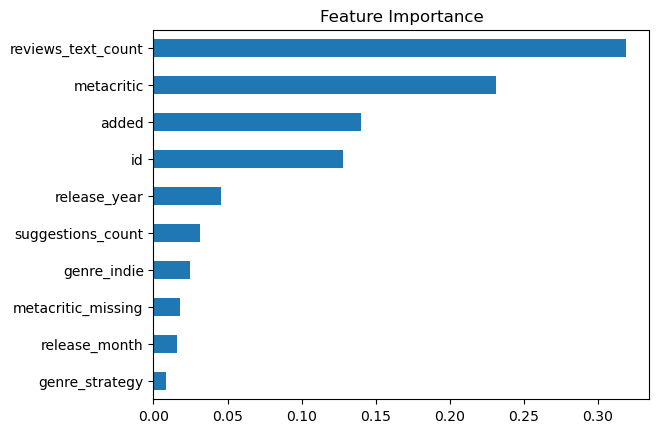

In [25]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [26]:
results = X_test.copy()
results["name"] = df.loc[X_test.index, "name"]
results["real"] = y_test
results["pred"] = y_pred

results.head(10)

,reviews_text_count,metacritic,added,suggestions_count,id,release_year,release_month,metacritic_missing,genre_action,genre_adventure,...,genre_puzzle,genre_rpg,genre_racing,genre_shooter,genre_simulation,genre_sports,genre_strategy,name,real,pred
1580,0,77.243728,1751,295,1587,2011.0,1.0,1,1,1,...,1,0,0,0,0,0,0,Grimm - GameClub,0,0
1742,2,80.000000,1618,523,1752,2013.0,10.0,0,1,1,...,0,0,0,0,0,0,0,NARUTO SHIPPUDEN: Ultimate Ninja STORM 3 Full ...,0,0
772,2,76.000000,3086,439,773,2017.0,4.0,0,1,1,...,0,0,0,0,0,0,0,Bulletstorm: Full Clip Edition,0,0
1744,3,73.000000,1617,376,1754,2017.0,3.0,0,1,1,...,0,0,0,0,0,0,0,Kona,0,0
387,4,85.000000,5149,659,388,2015.0,10.0,0,0,1,...,0,0,0,0,0,0,0,Tales from the Borderlands: A Telltale Game Se...,1,1
407,5,73.000000,4979,636,408,2015.0,11.0,0,1,1,...,0,0,0,1,0,0,1,STAR WARS Battlefront,0,0
2290,0,77.243728,1198,387,2376,2015.0,8.0,1,1,0,...,0,0,0,0,0,0,0,PAC-MAN 256,0,0
1116,0,81.000000,2322,479,1117,2015.0,9.0,0,1,0,...,0,0,0,0,0,0,0,World of Warships,0,0
2444,0,77.000000,1100,339,2579,2014.0,10.0,0,1,0,...,0,0,0,0,0,0,0,Pix the Cat,0,0
2751,1,77.243728,936,213,3039,2024.0,8.0,1,1,1,...,0,1,0,0,0,0,0,Core Keeper,0,0


In [27]:
df["metacritic"].isna().sum()

np.int64(0)

In [ ]:
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

def predecir_exito(selected_genres):
    
    input_data = pd.DataFrame(np.zeros((1, len(X.columns))), columns=X.columns)
    
    for genre in selected_genres:
        col_name = f"genre_{genre.lower().replace(' ', '_')}"
        if col_name in input_data.columns:
            input_data[col_name] = 1
    
    for col in ["reviews_text_count", "metacritic", "added", "suggestions_count"]:
        if col in input_data.columns:
            input_data["reviews_text_count"] = df["reviews_text_count"].quantile(0.75)
            input_data["metacritic"] = 85
            input_data["added"] = df["added"].quantile(0.75)
            input_data["suggestions_count"] = df["suggestions_count"].quantile(0.75)
    
    if "release_year" in input_data.columns:
        input_data["release_year"] = df["release_year"].mean()
        
    if "release_month" in input_data.columns:
        input_data["release_month"] = 6
    
    if "metacritic_missing" in input_data.columns:
        input_data["metacritic_missing"] = 0
    
    prob = model.predict_proba(input_data)[0][1]
    pred = 1 if prob > 0.4 else 0
    prob = model.predict_proba(input_data)[0][1]
    
    return pred, prob


genres = [col.replace("genre_", "").replace("_", " ").title() 
          for col in X.columns if col.startswith("genre_")]

genres_widgets = {g: widgets.Checkbox(description=g) for g in genres}

genres_box = widgets.VBox(list(genres_widgets.values()))

button = widgets.Button(
    description="Predecir",
    button_style="success"
)

output = widgets.Output()


def on_button_click(b):
    with output:
        clear_output()
        
        selected_genres = [g for g, w in genres_widgets.items() if w.value]
        
        if len(selected_genres) == 0:
            print(" Selecciona al menos un género")
            return
        
        pred, prob = predecir_exito(selected_genres)
        
        if pred == 1:
            print(f" Será un ÉXITO")
            print(f"Probabilidad: {prob:.2f}")
        else:
            print(f" No será un éxito")
            print(f"Probabilidad: {prob:.2f}")

button.on_click(on_button_click)


display(
    widgets.Label("Selecciona géneros:"),
    genres_box,
    button,
    output
)

Label(value='Selecciona géneros:')

Button(button_style='success', description='Predecir', style=ButtonStyle())

Output()

In [29]:
import joblib
from pathlib import Path

artifacts_dir = (Path("..") / ".." / "artifacts").resolve()
artifacts_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(model, artifacts_dir / "success_model.joblib")
joblib.dump(list(X.columns), artifacts_dir / "success_features.joblib")

stats = {
    "reviews_text_count_q75": float(df["reviews_text_count"].quantile(0.75)) if "reviews_text_count" in df.columns else 0.0,
    "added_q75": float(df["added"].quantile(0.75)) if "added" in df.columns else 0.0,
    "suggestions_count_q75": float(df["suggestions_count"].quantile(0.75)) if "suggestions_count" in df.columns else 0.0,
    "metacritic_default": 85.0,
    "release_year_mean": float(df["release_year"].mean()) if "release_year" in df.columns else 0.0,
    "release_month_default": 6.0,
    "threshold": 0.4,
}
joblib.dump(stats, artifacts_dir / "success_stats.joblib")

print("Guardado en:", artifacts_dir)


Guardado en: C:\Users\JuanR\Desktop\artifacts
